In [1]:
# Define the verbose variable
verbose = False

# Check if we're running in a Jupyter Notebook (not compiled script)
try:
    __IPYTHON__
    verbose = True  # Set verbose to True if running in a Jupyter Notebook
except NameError:
    pass  # Do nothing if we're not in a notebook

In [2]:
# All the imports

import torch
from torch.utils.data import TensorDataset
from torch import nn
import matplotlib.pyplot as plt

from load_dataset import labelList, get_data
from preprocess import preprocess_dataset
import bigmodel

from ml_util.eeg_util import plotEEG, plotTimeFreqEEG
from ml_util.checkpoint import checkpoint
from ml_util.data_module import DataModule
from ml_util.trainer import GoodClassificationModel, GoodTrainer
from ml_util.logger import WandBReporter, print_stats


torch.manual_seed(42)

In [3]:
print("Loading raw dataset")
X_raw, y = checkpoint(lambda: get_data(verbose=True), "raw_input")

Loading raw dataset


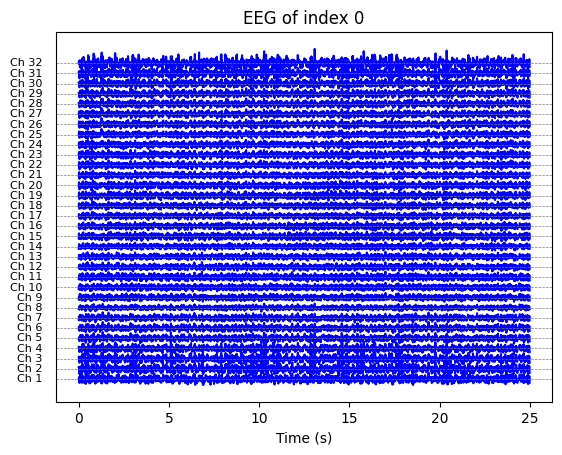

Arithmetic


In [4]:
if verbose:
    plotEEG(X_raw[0], title="index 0")
    print(labelList[y[0]])

In [5]:
hyperparams = {"bands_param": 1} # hop time in seconds

# Applies preprocessing
print("Preprocessing input data")
X = checkpoint(lambda : preprocess_dataset(X_raw, hyperparams["bands_param"], verbose=True), "preprocessed")
print(f"Input dataset shape: {X.shape}")

# Stores in a TensorDataset
dataset = DataModule(X, y, val_part=0.2, test_part=0)

# Uncomment to try overfitting
#dataset = dataset.get_part(0.25)

Preprocessing input data
Input dataset shape: torch.Size([480, 32, 19, 85])


<Figure size 640x480 with 0 Axes>

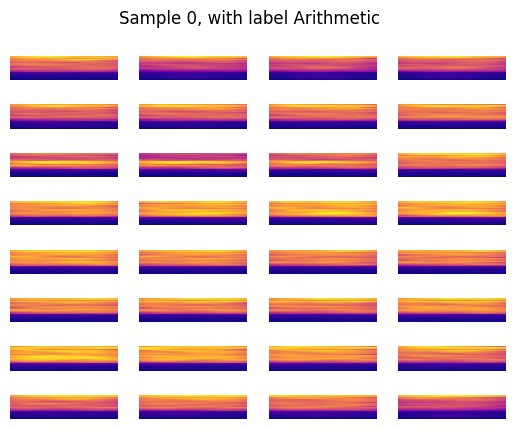

<Figure size 640x480 with 0 Axes>

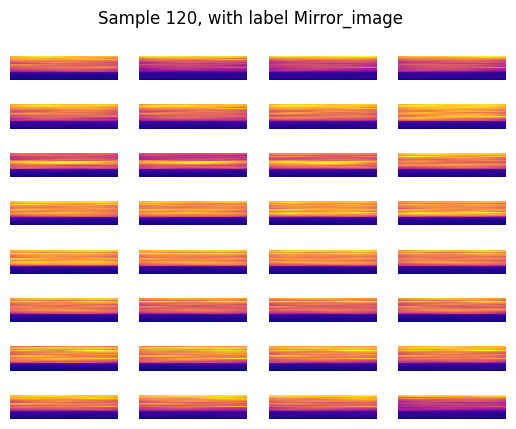

<Figure size 640x480 with 0 Axes>

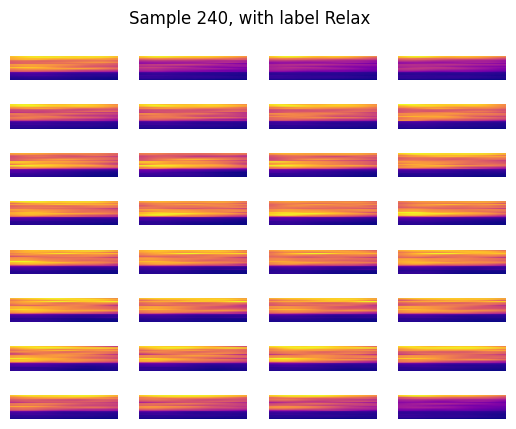

<Figure size 640x480 with 0 Axes>

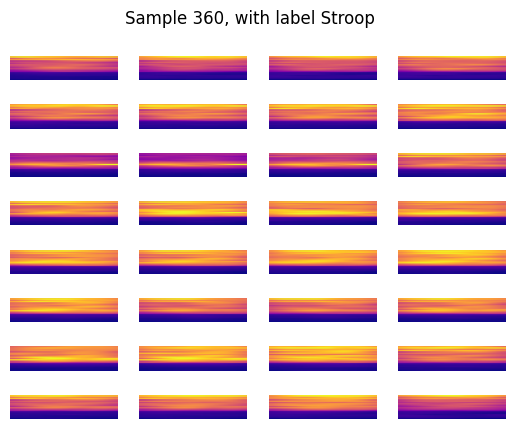

In [6]:
if verbose:
    for label in range(4):
        sampleId = torch.where(y==label)[0][0]
        plt.figure()
        fig, axes = plotTimeFreqEEG(X[sampleId])
        #plt.imshow(X[sampleId][0])
        fig.suptitle(f"Sample {sampleId}, with label {labelList[y[sampleId]]}")
    plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU" if torch.cuda.is_available() else "CPU")

hyperparams |= {
    'lr': 7e-4,
    'weight_decay': 2e-4,
    'batch_size': 16
}
model = bigmodel.model(X[0], hyperparams)
loss_fn = nn.CrossEntropyLoss()

classification_model = GoodClassificationModel(model, loss_fn, hyperparams, device, 4)
trainer = GoodTrainer()

def babysitter(goodModel):
    if (goodModel.epoch %  10 == 0):
        goodModel.hyperparameters['lr'] = 0.9 * goodModel.hyperparameters['lr']

trainer.add_babysitter(babysitter)
trainer.add_logger(print_stats)
trainer.add_logger(WandBReporter(hyperparams, labelList))

CPU


wandb: Currently logged in as: ulyssedurand (ulyssedurand-ens-de-lyon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
trainer.train(classification_model, dataset, 1000)

Epoch:    1    | tl: 1.504367, ta: 0.286458    |    vl: 1.387741, va: 0.208333
Epoch:    2    | tl: 1.484101, ta: 0.276042    |    vl: 1.468856, va: 0.229167
Epoch:    3    | tl: 1.457832, ta: 0.242188    |    vl: 1.413420, va: 0.270833
Epoch:    4    | tl: 1.416279, ta: 0.281250    |    vl: 1.405110, va: 0.229167
Epoch:    5    | tl: 1.423264, ta: 0.281250    |    vl: 1.389272, va: 0.312500
Epoch:    6    | tl: 1.411850, ta: 0.281250    |    vl: 1.399839, va: 0.281250
Epoch:    7    | tl: 1.409004, ta: 0.265625    |    vl: 1.387115, va: 0.291667
Epoch:    8    | tl: 1.403367, ta: 0.257812    |    vl: 1.388204, va: 0.302083
Epoch:    9    | tl: 1.424228, ta: 0.239583    |    vl: 1.396469, va: 0.291667
Epoch:   10    | tl: 1.414357, ta: 0.270833    |    vl: 1.388758, va: 0.229167
Epoch:   11    | tl: 1.429708, ta: 0.236979    |    vl: 1.387113, va: 0.197917
Epoch:   12    | tl: 1.409145, ta: 0.247396    |    vl: 1.391041, va: 0.229167
Epoch:   13    | tl: 1.416066, ta: 0.223958    |    